<a href="https://colab.research.google.com/github/jmcardenas8/Notebooks-Pregrado-Astronomia/blob/main/Termodinamica/Termo8_jm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trabajo Python 8:  
<br>

### &nbsp; **Termodinamica:**

>  &nbsp; &nbsp; *Juan Manuel Cárdenas*


<br>

___

<br>


**ejercicio 8.31.** <br>

Una barra conductora de calor, homogénea, de longitud L, densidad $ρ$, área de sección transversal A, y capacidad calorífica a presión constante $C_P$, tiene una distribución no uniforme de temperatura al
conectarse uno de sus extremos ($x = 0$) a un reservorio de alta temperatura ($T_0$) y el otro extremo ($x = L$) a
un reservorio de baja temperatura ($T_L$). <br>

En el estado inicial, la temperatura varía linealmente de un extremo al otro de acuerdo a la ecuación: (ver lado izquierdo de la figura 5).<br>
$$T_i = T_0 + \frac{T_L-T_0}{L}x $$
 <br><br>

* **(a)** La barra es removida de los dos reservorios y luego aislada térmicamente con paredes adiabáticas a presión constante $P cte$. <br>
Un flujo interno de calor llevará la barra a un estado final de distribución uniforme de temperatura, con: (ver figura 5).
$$T_f = (T_L+T_0)/2 $$ <br>
En este caso el cambio de entropía del universo está dado por:

$$\Delta S = C_P [1 - ln (\frac{T_L}{T_f}) + \frac{T_0}{T_0-T_L}  ln (\frac{T_0}{T_l}) ]$$ <br><br>



* **(b)** Ahora, en el caso en que a la barra uniforme en el estado final
solamente se le remueve el reservorio caliente, entonces el cambio de entropía del universo está dado por:
$$\Delta S = C_P (1+
\frac{T_0-T_L}{2 T_L}
-\frac{T_0}{T_0-T_L} ln(\frac{T_0}{T_L})) $$


<p align="center">
<img src=https://i.postimg.cc/Pq0x1NYZ/termo8.png width="500">
</p>


* **(c)** Utilizando Python, realice diagramas de $\Delta S$ versus $T_L$ para
distintos valores de $L$, $T_0$ y $C_P$ (capacidades caloríficas de barras conductoras de diferentes materiales, por
ejemplo de **Al**, de **Cu**, ó de **Fe**, etc.) y para las dos situaciones ilustradas en los apartados (a) y (b). Compare y discuta los resultados obtenidos.



In [ ]:
# librerias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy import constants

In [ ]:
# Materiales de las barras
barras = ['Al','Cu','Fe', 'Au'] # https://www.fbioyf.unr.edu.ar/evirtual/pluginfile.php/256227/mod_resource/content/1/TABLAS%20DE%20CONSTANTES%202023.pdf
C_p = np.array([24.2, 24.4, 25.1, 25.4]) # J/ (mol K)

# Temperaturas [K]
T_o = 100 # 1, 10, 100, 300
T_l = np.linspace(0.1, T_o-0.1, 400) # dominio
T_f = (T_o + T_l)/2

"""como se tiene que el lado final de la barra L, se encuentra a una
menor temperatura que el lado inicial, entonces se decidió poner una
cota limite al dominio de temperatura T_l, restringiendolo siempre a
valores menores que T_o
"""

In [ ]:
# funciones de cambio de S para ambos casos

def ΔS_A( C_p, T_o, T_f, T_l ):
  return  C_p*( 1 - np.log(T_l/T_f) +  T_o/(T_o-T_l)*np.log(T_o/T_l) )


def ΔS_B( C_p, T_o, T_f, T_l ):
  return C_p*(1 +  (T_o-T_l)/(2*T_l) - T_o/(T_o-T_l)*np.log(T_o/T_l))


In [ ]:
# calculo del cambio para las distintas barras

ΔS_a = np.zeros( (len(C_p), len(T_l)) )
ΔS_b = np.zeros( (len(C_p), len(T_l)) )


for i in range(len(C_p)):

  ΔS_a[i] = ΔS_A( C_p[i], T_o, T_f, T_l )

  ΔS_b[i] = ΔS_B( C_p[i], T_o, T_f, T_l )


Grafica superpuesta de ambos casos

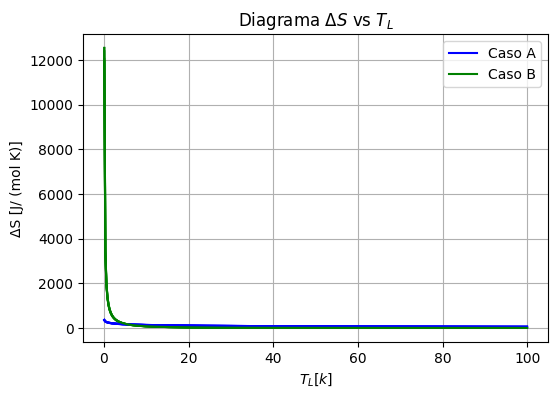

In [ ]:
plt.figure(figsize=(6,4))
plt.title('Diagrama $ΔS$ vs $T_L$')
plt.ylabel('ΔS [J/ (mol K)]')
plt.xlabel('$T_L [k]$')

plt.plot(T_l, ΔS_a[i], 'b', label='Caso A')
plt.plot(T_l, ΔS_b[i], 'g', label='Caso B')

for i in range(len(C_p)):
  plt.plot(T_l, ΔS_a[i], 'b')
  plt.plot(T_l, ΔS_b[i], 'g')

plt.legend()
plt.grid()

Grafica por separado para ambos casos:

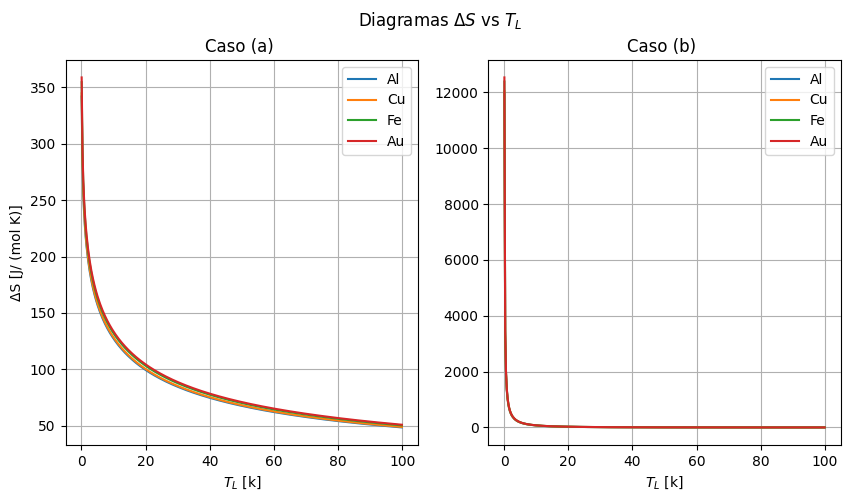

In [ ]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10,5))

fig.suptitle('Diagramas $ΔS$ vs $T_L$')
ax[0].set_ylabel('ΔS [J/ (mol K)]')
ax[0].set_xlabel('$T_L$ [k]')
ax[1].set_xlabel('$T_L$ [k]')



for i in range(len(C_p)):
  ax[0].plot( T_l, ΔS_a[i], label=f'{barras[i]}' )
  ax[1].plot( T_l, ΔS_b[i], label=f'{barras[i]}' )


ax[0].set_title('Caso (a) ')
ax[1].set_title('Caso (b) ')
ax[0].legend()
ax[1].legend()
ax[0].grid()
ax[1].grid()


### **Interpretacion**

Se encontró que el cambio en la entropia del universo para el caso **b**, donde la barra se deja conectada al reservorio de baja temperatura siempre es mayor que el entropia del universo del caso **a**.

este cambio de entropia para los $T_o$ probados, siempre tiene una tendencia decreciente, por otra parte, si se toma una dominio de temperaturas $T_L$ mas amplio sin la cota de menor a $T_o$ la cuerva del cambio de S para el segundo caso puede generar una exepcion, pues en los casos donde $T_o$ toma valores pequeños, en el caso b, la forma del cambio de entropia del universo decae a un pozo a bajas temperaturas de $T_L$ y luego aumenta monotona y asinototicamente a un valor cercano al de la asintota horizontal del caso a.

Para los distintos materiales no se presenta una gran diferencia, pero se observa que en el caso b, el mayor cambio de S que se presenta es para la barra de cobre, al tener una mayor capacidad calorifica a presion constante, y observado las ecuaciones del cambio de S, como $C_p$ es un factor del termino dependiente delas temperaturas, se podria afirmar que mientras el $C_p$ sea mayor, el cambio en la entropia será mayor tambien.

